# Real-time TDDFT optical spectrum with QEpy

Ground-state SCF, then real-time TDDFT (ce-tddft) to get the optical absorption of a molecule.

The example is ethylene (C₂H₄). Swap `atoms` for any ASE molecule. Pseudopotentials come from [KSPP](https://github.com/Quantum-MultiScale/KSPP) via `ksppresolver=True` — no local UPF directory.

**Needs:** QEpy (with ce-tddft), ASE, NumPy, Matplotlib. Network the first time KSPP downloads a UPF; after that the cache is local.

**Workflow**

1. SCF — `Driver(..., task='scf')`, then `save()` so TDDFT can restart from the same `outdir`
2. Propagate — `task='optical'`, `diagonalize()` once per time step, collect the dipole
3. Spectrum — Fourier-transform the dipole response

`&inputtddft` `prefix` / `tmp_dir` must match the SCF `prefix` / `outdir`. ce-tddft does not support `k_points gamma`, so use a 1×1×1 grid.


In [ ]:
# --- optional pip installs (normally leave collapsed / do not run) ---
!tddft=yes python -m pip install qepy f90wrap==0.2.16
!pip install dftpy
!pip install matplotlib

## 1. System and QE input

Replace `atoms` with any ASE molecule and put it in a large enough box (here 10 Å). `Driver` fills `nat`, cell, and positions.

`TABLE` selects the KSPP library. ONCV (`norm-conserving/nc-sr-05`) is a typical choice for real-time TDDFT.

What matters in `qe_options`:

- `nbnd` — occupied bands plus a few empty ones (needed for the optical response)
- `nosym = True` — do not let symmetry kill the dipole
- `k_points automatic = 1 1 1` — not `gamma`; ce-tddft aborts on `gamma_only`
- `&inputtddft`: `dt` (attoseconds), `nstep`, `e_direction` (1/2/3 = x/y/z)
- TDDFT `prefix` / `tmp_dir` are copied from SCF `&control` so both runs share the same save directory


In [1]:
import numpy as np
from ase.build import molecule
from qepy.driver import Driver

atoms = molecule("C2H4")
atoms.set_cell(np.identity(3) * 10)
atoms.translate([5, 5, 5])

# Change TABLE to switch PP library (None → KSPP default GBRV ultrasoft)
TABLE = "norm-conserving/nc-sr-05"

qe_options = {}

qe_options["&control"] = {}
qe_options["&control"]["calculation"] = "'scf'"
qe_options["&control"]["prefix"] = "'c2h4'"
qe_options["&control"]["restart_mode"] = "'from_scratch'"
qe_options["&control"]["outdir"] = "'tmp/'"

qe_options["&system"] = {}
qe_options["&system"]["ibrav"] = 0
qe_options["&system"]["ecutwfc"] = 50
qe_options["&system"]["nosym"] = True
qe_options["&system"]["nbnd"] = 10
qe_options["&system"]["occupations"] = "'smearing'"
qe_options["&system"]["smearing"] = "'gaussian'"
qe_options["&system"]["degauss"] = 0.001

qe_options["&electrons"] = {}
qe_options["&electrons"]["conv_thr"] = 1.0e-9

# not gamma: ce-tddft aborts on gamma_only
qe_options["k_points automatic"] = ["1 1 1 0 0 0"]

qe_options["&inputtddft"] = {}
qe_options["&inputtddft"]["job"] = "'optical'"
qe_options["&inputtddft"]["prefix"] = qe_options["&control"]["prefix"]
qe_options["&inputtddft"]["tmp_dir"] = qe_options["&control"]["outdir"]
qe_options["&inputtddft"]["dt"] = 2.0
qe_options["&inputtddft"]["nstep"] = 2000
qe_options["&inputtddft"]["e_direction"] = 1  # 1/2/3 = x/y/z

print(atoms)


Atoms(symbols='C2H4', pbc=False, cell=[10.0, 10.0, 10.0])


## 2. Ground-state SCF

### Initialize the Driver

`task='scf'` with `ksppresolver=True`. `&inputtddft` can already be in `qe_options`; it is used in the next section.


In [6]:
driver = Driver(
    qe_options=qe_options,
    atoms=atoms,
    ksppresolver=True,
    table=TABLE,
    task="scf",
    logfile="tmp.out",
)


### Run SCF

`driver.scf()` converges the ground-state density. The return value is the total energy in Ry.

In [7]:
driver.scf()

-28.731817873623022

### Save the wavefunctions

`save()` writes orbitals and eigenvalues to `outdir`. `stop()` finalizes QE so the `.save` is flushed. The optical run reads this restart.

In [8]:
driver.save()
driver.stop()

## 3. Real-time TDDFT

Same `qe_options`, `atoms`, and `outdir` as the SCF.

- `task='optical'` — ce-tddft
- `iterative=True` — each `diagonalize()` advances one step of length `dt`
- `get_dipole_tddft()` — dipole (x, y, z) after that step

A δ-kick along `e_direction` is applied at *t* = 0. The loop stores the oscillating dipole in `mu_t` for `nstep` steps.


In [ ]:
driver_td = Driver(
    qe_options=qe_options,
    atoms=atoms,
    ksppresolver=True,
    table=TABLE,
    task="optical",
    iterative=True,
    logfile="rt_tmp.out",
)

nstep = qe_options["&inputtddft"]["nstep"]
mu_t = np.zeros((nstep, 3))
for i in range(nstep):
    driver_td.diagonalize()
    mu_t[i] = np.asarray(driver_td.get_dipole_tddft()).ravel()

driver_td.stop()

## 4. Absorption spectrum

### Fourier transform

Subtract the *t* = 0 dipole, apply a Gaussian damping window, and sine-transform along the kick axis (`e_direction`). ce-tddft `dt` is in attoseconds; `ATTO` / `EV_J` / `HBAR` put *E*·*t* in eV.

`e_strength` and `damping` are analysis parameters, not QE input. Raise `nstep` for finer frequency resolution.


In [ ]:
import matplotlib.pyplot as plt

dt = qe_options["&inputtddft"]["dt"]
idir = qe_options["&inputtddft"]["e_direction"] - 1
e_strength, damping = 0.01, 0.02
ATTO, EV_J, HBAR = 1e-18, 1.602176634e-19, 1.054571817e-34

mu = mu_t[:, idir] - mu_t[0, idir]
t = np.arange(mu.size) * dt * ATTO * EV_J / HBAR
w = np.exp(-(t ** 2) * damping)

E = np.linspace(0, 20, 2000)
S = np.array([np.sum(mu * w * np.sin(e * t)) * e for e in E])
S *= 2 * dt * ATTO * EV_J / HBAR / (e_strength * np.pi)
print(S)

[ 0.00000000e+00 -2.66903402e-07 -1.05706547e-06 ...  6.38887755e+00
  6.51635976e+00  6.64082591e+00]


### Plot

Intensity vs photon energy. The ethylene π → π* peak usually sits in this window; change `xlim` for other molecules.

(3.0, 10.0)

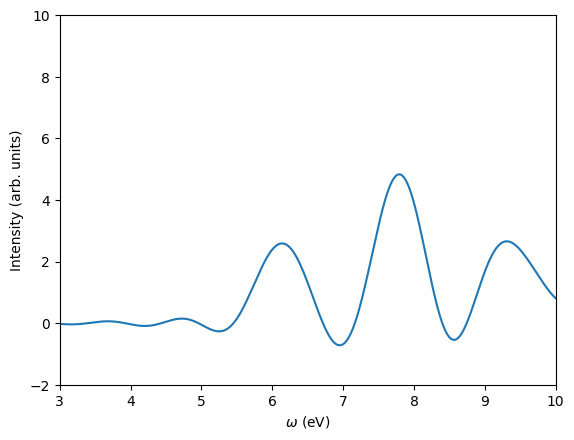

In [ ]:
plt.plot(E, S)
plt.xlabel(r'$\omega$ (eV)')
plt.ylabel(r'Intensity (arb. units)')
plt.ylim(-2,10)
plt.xlim([3,10])